# Iris flower classification using Machine Learning

## Importing dependencies

In [1]:

# core dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib_inline    


In [2]:
columns =['Sepal length', 'Sepal width', 'Petal length', 'Petal width', 'Class_labels'] 

# Load data

data_location = (r'D:\Robotics\Machine Learning Projects\Iris classification\data\iris.data')
df = pd.read_csv(data_location,names=columns)

In [3]:
df.head()

,Sepal length,Sepal width,Petal length,Petal width,Class_labels
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


Dimensions of the data

In [27]:
print("Dimensions :",df.shape)

Dimensions : (150, 5)


## Step 2 : Analyze and Visualize data

In [4]:
df.shape

(150, 5)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Sepal length  150 non-null    float64
 1   Sepal width   150 non-null    float64
 2   Petal length  150 non-null    float64
 3   Petal width   150 non-null    float64
 4   Class_labels  150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [6]:
df['Class_labels'].value_counts()

Class_labels
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [7]:
df.describe()

,Sepal length,Sepal width,Petal length,Petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Let's visualise the data

Firstly understand the distribution

Text(0, 0.5, 'count')

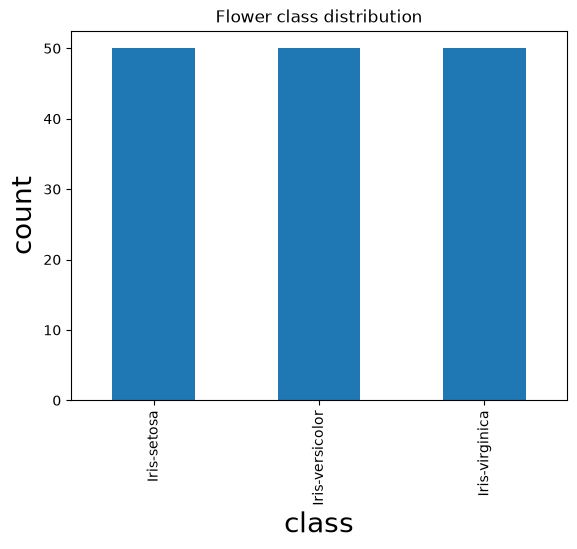

In [8]:
nameplot = df['Class_labels'].value_counts().plot.bar(title ='Flower class distribution')
nameplot.set_xlabel('class',size=20)
nameplot.set_ylabel('count',size = 20)

From the above we can summarize that the distribution of the class is equal in the dataset . It is very 'Ideal' In machine Learning projects . 

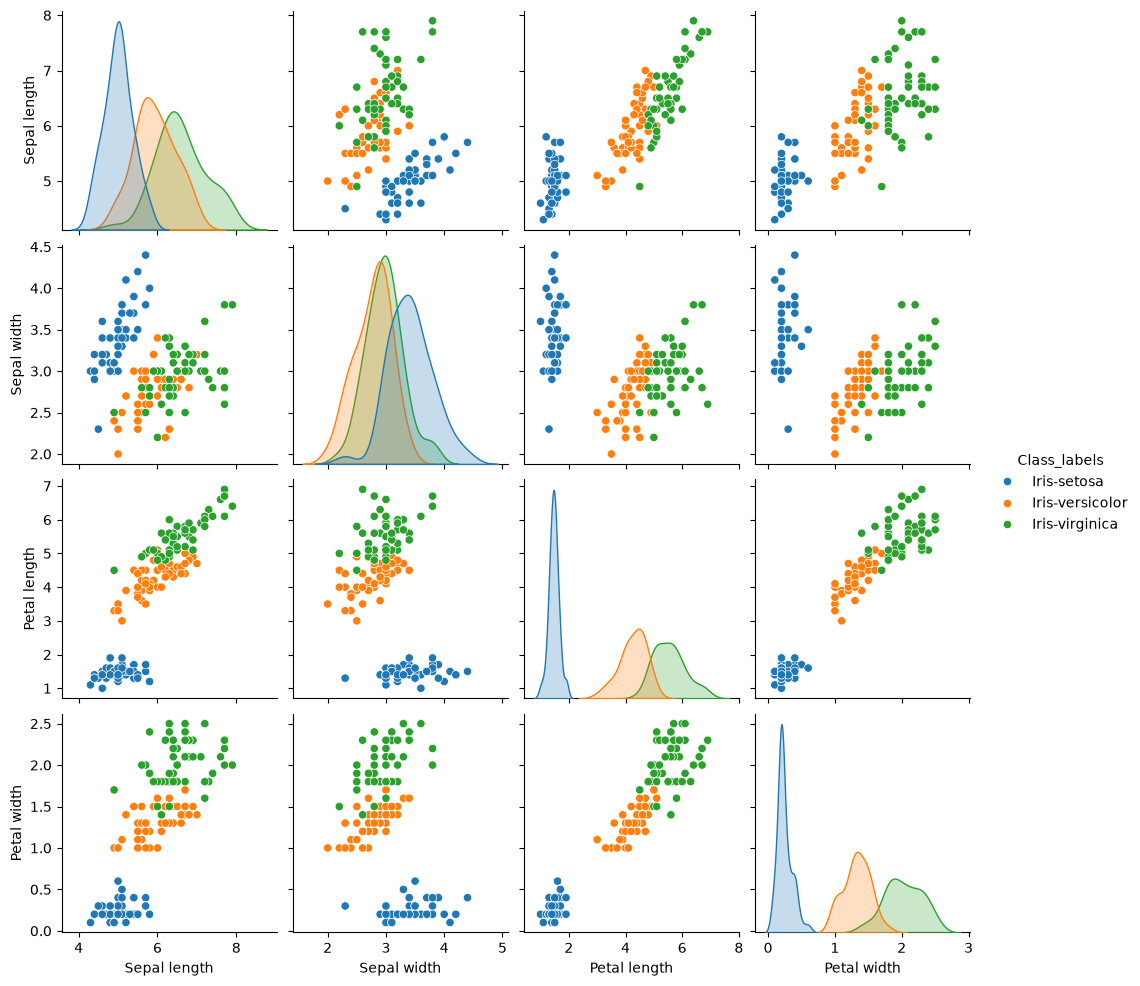

In [9]:
sns.pairplot(df,hue='Class_labels')

Sepal length       Axes(0.125,0.53;0.352273x0.35)
Sepal width     Axes(0.547727,0.53;0.352273x0.35)
Petal length       Axes(0.125,0.11;0.352273x0.35)
Petal width     Axes(0.547727,0.11;0.352273x0.35)
dtype: object

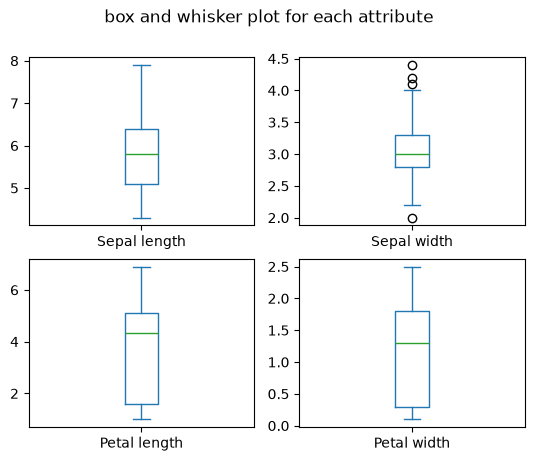

In [10]:
df.plot(kind='box',subplots=True , layout=(2,2)
        , sharex=False, sharey=False, title="box and whisker plot for each attribute")

Histograms

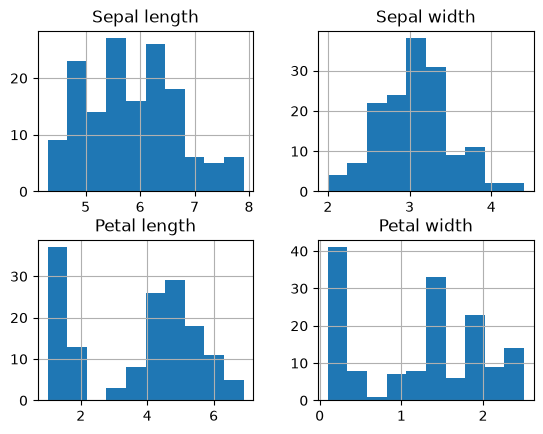

In [11]:
df.hist()
plt.show()

From the above histplot we can see that two of the above features have normal distribution . This is the assumption of many machine learning model we can use that to advantage to model the data

## Data Modeling

Classification Problem : our goal is to determine the type of iris based on given 4 featurses : 'Sepal length', 'Sepal width', 'Petal length', 'Petal width'

Our X will be the features and Y will be the target Class 

## Train test split

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
df.columns

Index(['Sepal length', 'Sepal width', 'Petal length', 'Petal width',
       'Class_labels'],
      dtype='str')

In [14]:
features = ['Sepal length', 'Sepal width', 'Petal length', 'Petal width']
labels = ['Class_labels']

In [15]:
x = df[features]
y = df[labels]

In [16]:
x.head()

,Sepal length,Sepal width,Petal length,Petal width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [17]:
x_train , x_test,y_train , y_test = train_test_split(x,y,random_state=42,test_size=0.2) 

In [18]:
print("shape of x_train :",x_train.shape)
print("shape of x_test :",x_test.shape)
print("Shape of y_train:",y_train.shape)
print("Shape of y_test : ",y_test.shape)


shape of x_train : (120, 4)
shape of x_test : (30, 4)
Shape of y_train: (120, 1)
Shape of y_test :  (30, 1)


### Model Building

In [30]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

Training the Model and Evaluate with 10 k fold

In [31]:
# models
models = []

# linear models
models.append(('LR', LogisticRegression(solver='lbfgs', max_iter=1000)))  # Removed multi_class
models.append(('LDA', LinearDiscriminantAnalysis()))

# nonlinear models
models.append(('CART', DecisionTreeClassifier()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('GNB', GaussianNB()))
models.append(('SVC', SVC(gamma="auto")))

# evaluate each model in turn
print("Model Accuracy:")
names = []
accuracy = []
for name, model in models:
    kfold = KFold(n_splits=10, shuffle=True, random_state=7)
    cv_results = cross_val_score(model, x_train, y_train, cv=kfold, scoring='accuracy')
    
    names.append(name)
    accuracy.append(cv_results)
    msg = "%s: accuracy=%f std=(%f)" % (name, cv_results.mean(), cv_results.std())
    print(msg)

Model Accuracy:
LR: accuracy=0.966667 std=(0.040825)
LDA: accuracy=0.966667 std=(0.040825)
CART: accuracy=0.933333 std=(0.050000)
KNN: accuracy=0.950000 std=(0.055277)
GNB: accuracy=0.941667 std=(0.053359)
SVC: accuracy=0.958333 std=(0.055902)


Test the KNN, GNB, and SVC models with test data and output their accuracy with confusion matrix together for selecting model

In [35]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [36]:
# models
models = []
models.append(('KNN',KNeighborsClassifier()))
models.append(('GNB',GaussianNB))
models.append(('SVC',SVC(gamma="auto")))

In [37]:
# reusable function to test our model
def test_model(model):
    model.fit(x_train, y_train) # train the whole training set
    predictions = model.predict(x_test) # predict on test set
    
    # output model testing results
    print("Accuracy:", accuracy_score(y_test, predictions))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))
    print("Classification Report:")
    print(classification_report(y_test, predictions))

In [ ]:
# predict values with our test set
for name, model in models:
    print("----------------")
    print("Testing", name)
    test_model(model)